<a href="https://colab.research.google.com/github/Park-Joyeong/hongong-machine-learning/blob/main/09_2_PyTorch_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(train_seq.shape, train_target.shape)

(20000, 100) (20000,)


In [4]:
train_seq = torch.tensor(train_seq)
val_seq = torch.tensor(val_seq)

In [5]:
print(train_target.dtype)

int64


In [6]:
train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)

In [7]:
print(train_target.dtype)

torch.float32


In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_seq, train_target)
val_dataset = TensorDataset(val_seq, val_target)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [9]:
import torch.nn as nn

class IMDBRnn(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(500, 16)
        self.rnn = nn.RNN(16, 8, batch_first=True)
        self.dense = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        outputs = self.dense(hidden[-1])
        return self.sigmoid(outputs)

In [10]:
model = IMDBRnn()

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

IMDBRnn(
  (embedding): Embedding(500, 16)
  (rnn): RNN(16, 8, batch_first=True)
  (dense): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [11]:
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

In [12]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 100
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            val_loss += loss.item()

    train_loss = train_loss/len(train_loader)
    val_loss = val_loss/len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},",
          f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_rnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.7065, 검증 손실:0.6978
에포크:2, 훈련 손실:0.6962, 검증 손실:0.6955
에포크:3, 훈련 손실:0.6933, 검증 손실:0.6941
에포크:4, 훈련 손실:0.6915, 검증 손실:0.6929
에포크:5, 훈련 손실:0.6900, 검증 손실:0.6919
에포크:6, 훈련 손실:0.6887, 검증 손실:0.6910
에포크:7, 훈련 손실:0.6874, 검증 손실:0.6897
에포크:8, 훈련 손실:0.6859, 검증 손실:0.6883
에포크:9, 훈련 손실:0.6843, 검증 손실:0.6872
에포크:10, 훈련 손실:0.6824, 검증 손실:0.6852
에포크:11, 훈련 손실:0.6804, 검증 손실:0.6834
에포크:12, 훈련 손실:0.6780, 검증 손실:0.6812
에포크:13, 훈련 손실:0.6752, 검증 손실:0.6788
에포크:14, 훈련 손실:0.6721, 검증 손실:0.6752
에포크:15, 훈련 손실:0.6683, 검증 손실:0.6712
에포크:16, 훈련 손실:0.6638, 검증 손실:0.6661
에포크:17, 훈련 손실:0.6581, 검증 손실:0.6602
에포크:18, 훈련 손실:0.6506, 검증 손실:0.6518
에포크:19, 훈련 손실:0.6423, 검증 손실:0.6416
에포크:20, 훈련 손실:0.6338, 검증 손실:0.6321
에포크:21, 훈련 손실:0.6251, 검증 손실:0.6233
에포크:22, 훈련 손실:0.6160, 검증 손실:0.6152
에포크:23, 훈련 손실:0.6085, 검증 손실:0.6095
에포크:24, 훈련 손실:0.5991, 검증 손실:0.6048
에포크:25, 훈련 손실:0.5922, 검증 손실:0.6019
에포크:26, 훈련 손실:0.5849, 검증 손실:0.5956
에포크:27, 훈련 손실:0.5799, 검증 손실:0.5884
에포크:28, 훈련 손실:0.5749, 검증 손실:0.5853
에포크:29, 훈련 손실:0.5700, 검증 손실:0

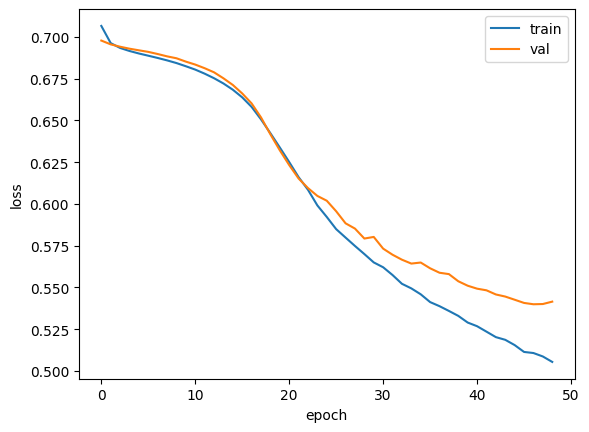

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [14]:
model.load_state_dict(torch.load('best_rnn_model.pt', weights_only=True))

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.7398
